# Lab 4.1 - Exercise 2: MNIST (MLP vs CNN)

**Student**: 22521609 - Pham Duy Tuan

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print('Torch version:', torch.__version__)

Torch version: 2.5.1+cu121


In [12]:
# Hyperparameters and device
BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 5
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [13]:
# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print('Train size:', len(train_dataset))
print('Test size :', len(test_dataset))

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

Train size: 60000
Test size : 10000


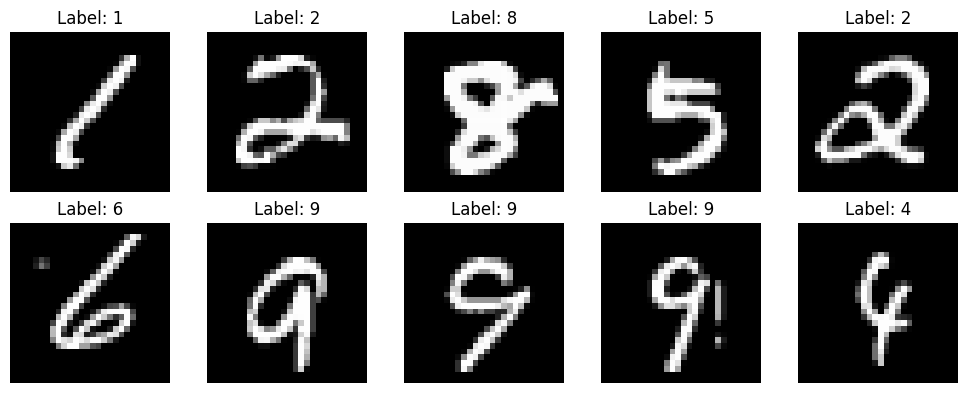

In [14]:
# Show sample images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze(0).numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [15]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total


def run_training(model, train_loader, test_loader, device, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'Train loss: {tr_loss:.4f}, acc: {tr_acc:.4f} | '
            f'Test loss: {te_loss:.4f}, acc: {te_acc:.4f}'
        )

    return history

In [17]:
# Train MLP
mlp_model = MLP().to(device)
print('Training MLP...')
history_mlp = run_training(
    mlp_model,
    train_loader,
    test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

Training MLP...
Epoch 01/5 | Train loss: 0.2693, acc: 0.9186 | Test loss: 0.1331, acc: 0.9603
Epoch 02/5 | Train loss: 0.1025, acc: 0.9683 | Test loss: 0.0905, acc: 0.9712
Epoch 03/5 | Train loss: 0.0694, acc: 0.9786 | Test loss: 0.0789, acc: 0.9750
Epoch 04/5 | Train loss: 0.0509, acc: 0.9839 | Test loss: 0.0813, acc: 0.9765
Epoch 05/5 | Train loss: 0.0396, acc: 0.9872 | Test loss: 0.0670, acc: 0.9800


In [18]:
# Train CNN
cnn_model = CNN().to(device)
print('Training CNN...')
history_cnn = run_training(
    cnn_model,
    train_loader,
    test_loader,
    device=device,
    epochs=EPOCHS,
    lr=LR,
)

Training CNN...
Epoch 01/5 | Train loss: 0.1659, acc: 0.9510 | Test loss: 0.0540, acc: 0.9831
Epoch 02/5 | Train loss: 0.0474, acc: 0.9850 | Test loss: 0.0295, acc: 0.9899
Epoch 03/5 | Train loss: 0.0321, acc: 0.9898 | Test loss: 0.0359, acc: 0.9882
Epoch 04/5 | Train loss: 0.0244, acc: 0.9923 | Test loss: 0.0294, acc: 0.9890
Epoch 05/5 | Train loss: 0.0174, acc: 0.9948 | Test loss: 0.0324, acc: 0.9894


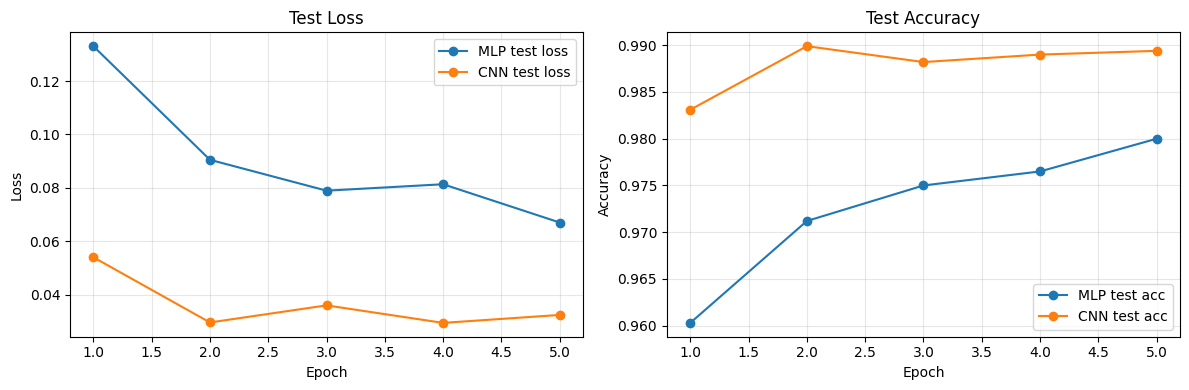

In [19]:
# Compare loss and accuracy
epochs_axis = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_axis, history_mlp['test_loss'], marker='o', label='MLP test loss')
axes[0].plot(epochs_axis, history_cnn['test_loss'], marker='o', label='CNN test loss')
axes[0].set_title('Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, history_mlp['test_acc'], marker='o', label='MLP test acc')
axes[1].plot(epochs_axis, history_cnn['test_acc'], marker='o', label='CNN test acc')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Final summary
mlp_final_acc = history_mlp['test_acc'][-1]
cnn_final_acc = history_cnn['test_acc'][-1]
mlp_final_loss = history_mlp['test_loss'][-1]
cnn_final_loss = history_cnn['test_loss'][-1]

print('Final test results:')
print(f'  MLP - acc: {mlp_final_acc:.4f}, loss: {mlp_final_loss:.4f}')
print(f'  CNN - acc: {cnn_final_acc:.4f}, loss: {cnn_final_loss:.4f}')

if cnn_final_acc > mlp_final_acc:
    print('\nConclusion: CNN performs better on MNIST in this run.')
elif cnn_final_acc < mlp_final_acc:
    print('\nConclusion: MLP performs better on MNIST in this run.')
else:
    print('\nConclusion: Both models have similar final accuracy in this run.')

Final test results:
  MLP - acc: 0.9800, loss: 0.0670
  CNN - acc: 0.9894, loss: 0.0324

Conclusion: CNN performs better on MNIST in this run.


: 